# EMNIST Digits — DCGAN CPU/GPU Benchmark
## Same model, same data, same training workload

### Research question

\[
\boxed{\text{DCGAN training on CPU vs the same DCGAN training on GPU}}
\]

This notebook is for a **hardware/platform comparison**, not a direct
VAE-vs-DCGAN efficiency ranking.

### Dataset

The complete standard EMNIST Digits split is used:

- **240,000 training images** for DCGAN training;
- **40,000 test images** retained as the standard dataset test partition.

DCGAN is trained only on the training split. CPU and GPU use the same fixed
training-image order.

### Fair-comparison controls

CPU and GPU use the same:

- generator architecture;
- discriminator architecture;
- batch size;
- epochs;
- latent dimension;
- Adam settings;
- random seed;
- training images;
- fixed latent vectors for generation benchmarking.

The complete training tensor is moved to the selected execution device before
timing and carbon tracking.

### Metrics

- DCGAN training time;
- training throughput;
- final generator/discriminator losses;
- image-generation/inference time;
- generation throughput;
- peak memory;
- CodeCarbon energy;
- CodeCarbon CO₂e.

### Carbon methodology

The clean complete training run is timed with CodeCarbon off.

Three separate steady-state CodeCarbon blocks measure the full GAN training
step—**one discriminator update plus one generator update**—for at least
60 seconds each.

Energy and CO₂e are normalized per 1,000 real training images and scaled to
the configured complete training workload.


## 1. Select CPU or GPU

In [1]:
# Change only this line for the two final experiments.
DEVICE = "cpu"          # "cpu" or "cuda"

DEVICE = DEVICE.lower().strip()

if DEVICE not in {"cpu", "cuda"}:
    raise ValueError("DEVICE must be 'cpu' or 'cuda'.")

print("Selected device:", DEVICE.upper())


Selected device: CPU


## 2. Imports and environment

In [2]:
import os
import gc
import sys
import time
import random
import threading
import subprocess
import importlib.util
from pathlib import Path

def ensure_package(module_name, package_name=None):
    if importlib.util.find_spec(module_name) is None:
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            package_name or module_name,
        ])

ensure_package("codecarbon")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil

import torch
import torch.nn as nn
from torchvision import datasets
from torchvision.utils import make_grid

from codecarbon import EmissionsTracker

device = torch.device(DEVICE)

if device.type == "cuda":
    if not torch.cuda.is_available():
        raise RuntimeError(
            "DEVICE='cuda' but CUDA is unavailable. "
            "Enable a Kaggle GPU accelerator."
        )
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)
else:
    print("CPU mode")
    print("Logical CPU cores:", os.cpu_count())

print("PyTorch:", torch.__version__)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.9/396.9 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 84.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 76.9 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
sigstore 4.3.0 requires cryptography<49,>=42, but you have cryptography 50.0.0 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 50.0.0 which is incompatible.
pyopenssl 24.2.1 requires cryptography<44,>=41.0.5, but you have cryptography 50.0.0 which is incompatible.


CPU mode
Logical CPU cores: 4
PyTorch: 2.10.0+cpu


## 3. Experimental configuration

In [3]:
SEED = 42

BATCH_SIZE = 256
EPOCHS = 5
LATENT_DIM = 100

LEARNING_RATE = 2e-4
BETA1 = 0.5
BETA2 = 0.999

GENERATION_SAMPLES = 10_000
GENERATION_BATCH_SIZE = 512
DISPLAY_SAMPLES = 64

CARBON_MEASURE_SECS = 1
ENERGY_BLOCKS = 3
ENERGY_MIN_DURATION_S = 60.0
ENERGY_COOLDOWN_S = 5.0

MEMORY_PROFILE_STEPS = 30

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

print({
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "latent_dim": LATENT_DIM,
    "learning_rate": LEARNING_RATE,
    "betas": (BETA1, BETA2),
    "energy_blocks": ENERGY_BLOCKS,
    "energy_min_duration_s": ENERGY_MIN_DURATION_S,
})


{'batch_size': 256, 'epochs': 5, 'latent_dim': 100, 'learning_rate': 0.0002, 'betas': (0.5, 0.999), 'energy_blocks': 3, 'energy_min_duration_s': 60.0}


## 4. Load full EMNIST Digits train/test tensors

The training images are orientation-corrected and normalized to \([-1,1]\),
matching the generator's `tanh` output.


In [4]:
train_ds = datasets.EMNIST(
    "./data",
    split="digits",
    train=True,
    download=True,
)

test_ds = datasets.EMNIST(
    "./data",
    split="digits",
    train=False,
    download=True,
)

assert len(train_ds) == 240_000
assert len(test_ds) == 40_000

def prepare_gan_images(raw):
    x = (
        raw
        .float()
        .transpose(1, 2)
        .unsqueeze(1)
        / 255.0
    )
    x = x * 2.0 - 1.0
    return x.contiguous()

X_train_cpu = prepare_gan_images(train_ds.data)
X_test_cpu = prepare_gan_images(test_ds.data)

rng = np.random.RandomState(SEED)
perm = torch.from_numpy(
    rng.permutation(len(X_train_cpu)).astype(np.int64)
)
X_train_cpu = X_train_cpu[perm].contiguous()

print("Train tensor:", tuple(X_train_cpu.shape))
print("Test tensor :", tuple(X_test_cpu.shape))
print("Train tensor size:", round(X_train_cpu.nbytes / (1024**2), 1), "MB")

X_train = X_train_cpu.to(device)
X_test = X_test_cpu.to(device)

if device.type == "cuda":
    torch.cuda.synchronize()

print("Execution tensor device:", X_train.device)


100%|██████████| 562M/562M [00:02<00:00, 197MB/s]


Train tensor: (240000, 1, 28, 28)
Test tensor : (40000, 1, 28, 28)
Train tensor size: 717.8 MB
Execution tensor device: cpu


## 5. DCGAN generator and discriminator

In [5]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()

        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 128 * 7 * 7),
            nn.BatchNorm1d(128 * 7 * 7),
            nn.ReLU(inplace=True),
        )

        self.net = nn.Sequential(
            nn.ConvTranspose2d(
                128, 64, kernel_size=4, stride=2, padding=1
            ),                                                     # 7 -> 14
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(
                64, 1, kernel_size=4, stride=2, padding=1
            ),                                                     # 14 -> 28
            nn.Tanh(),
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 128, 7, 7)
        return self.net(x)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(
                1, 64, kernel_size=4, stride=2, padding=1
            ),                                                     # 28 -> 14
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(
                64, 128, kernel_size=4, stride=2, padding=1
            ),                                                     # 14 -> 7
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
        )

    def forward(self, x):
        return self.net(x).view(-1)


def weights_init(module):
    if isinstance(
        module,
        (nn.Conv2d, nn.ConvTranspose2d, nn.Linear),
    ):
        nn.init.normal_(
            module.weight,
            0.0,
            0.02,
        )

        if module.bias is not None:
            nn.init.zeros_(module.bias)

    elif isinstance(
        module,
        (nn.BatchNorm1d, nn.BatchNorm2d),
    ):
        nn.init.normal_(
            module.weight,
            1.0,
            0.02,
        )
        nn.init.zeros_(module.bias)


def make_models(seed=SEED):
    set_seed(seed)

    G = Generator(
        LATENT_DIM
    ).to(device)

    D = Discriminator().to(device)

    G.apply(weights_init)
    D.apply(weights_init)

    opt_G = torch.optim.Adam(
        G.parameters(),
        lr=LEARNING_RATE,
        betas=(BETA1, BETA2),
    )

    opt_D = torch.optim.Adam(
        D.parameters(),
        lr=LEARNING_RATE,
        betas=(BETA1, BETA2),
    )

    return G, D, opt_G, opt_D


criterion = nn.BCEWithLogitsLoss()

G, D, opt_G, opt_D = make_models()

print("Generator parameters:", sum(p.numel() for p in G.parameters()))
print("Discriminator parameters:", sum(p.numel() for p in D.parameters()))


Generator parameters: 778305
Discriminator parameters: 138817


## 6. DCGAN training helpers

In [6]:
def sync_device():
    if device.type == "cuda":
        torch.cuda.synchronize()


def gan_training_step(
    real,
    G,
    D,
    opt_G,
    opt_D,
):
    batch_size = real.size(0)

    real_targets = torch.ones(
        batch_size,
        device=device,
    )

    fake_targets = torch.zeros(
        batch_size,
        device=device,
    )

    # --------------------------------------------------------
    # Discriminator update
    # --------------------------------------------------------
    opt_D.zero_grad(set_to_none=True)

    real_logits = D(real)

    d_real_loss = criterion(
        real_logits,
        real_targets,
    )

    z = torch.randn(
        batch_size,
        LATENT_DIM,
        device=device,
    )

    fake = G(z)

    fake_logits = D(
        fake.detach()
    )

    d_fake_loss = criterion(
        fake_logits,
        fake_targets,
    )

    d_loss = (
        d_real_loss
        + d_fake_loss
    )

    d_loss.backward()
    opt_D.step()

    # --------------------------------------------------------
    # Generator update
    # --------------------------------------------------------
    opt_G.zero_grad(set_to_none=True)

    generator_logits = D(fake)

    g_loss = criterion(
        generator_logits,
        real_targets,
    )

    g_loss.backward()
    opt_G.step()

    return (
        float(d_loss.item()),
        float(g_loss.item()),
    )


def train_one_epoch(
    G,
    D,
    opt_G,
    opt_D,
):
    G.train()
    D.train()

    d_total = 0.0
    g_total = 0.0
    steps = 0

    for start in range(
        0,
        len(X_train),
        BATCH_SIZE,
    ):
        real = X_train[
            start:start + BATCH_SIZE
        ]

        d_loss, g_loss = gan_training_step(
            real,
            G,
            D,
            opt_G,
            opt_D,
        )

        d_total += d_loss
        g_total += g_loss
        steps += 1

    return {
        "d_loss": d_total / steps,
        "g_loss": g_total / steps,
    }


## 7. Unmeasured warm-up

In [7]:
warm_G, warm_D, warm_opt_G, warm_opt_D = make_models(
    SEED + 999
)

real = X_train[:BATCH_SIZE]

_ = gan_training_step(
    real,
    warm_G,
    warm_D,
    warm_opt_G,
    warm_opt_D,
)

sync_device()

del warm_G, warm_D, warm_opt_G, warm_opt_D
gc.collect()

if device.type == "cuda":
    torch.cuda.empty_cache()

print("Warm-up complete.")


Warm-up complete.


## 8. Clean full DCGAN training benchmark

CodeCarbon is off during this training run. Each training batch performs the
same GAN workload:

\[
\boxed{\text{1 discriminator update + 1 generator update}}
\]


In [8]:
G, D, opt_G, opt_D = make_models(SEED)

history = []

sync_device()
training_start = time.perf_counter()

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.perf_counter()

    metrics = train_one_epoch(
        G,
        D,
        opt_G,
        opt_D,
    )

    sync_device()
    epoch_time = time.perf_counter() - epoch_start

    row = {
        "epoch": epoch,
        "epoch_time_s": epoch_time,
        **metrics,
    }

    history.append(row)

    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"time={epoch_time:.2f}s | "
        f"D loss={metrics['d_loss']:.4f} | "
        f"G loss={metrics['g_loss']:.4f}"
    )

sync_device()
training_time_s = time.perf_counter() - training_start

training_throughput = (
    len(X_train) * EPOCHS
    / training_time_s
)

history_df = pd.DataFrame(history)

print("\nClean training time:", round(training_time_s, 3), "s")
print("Training throughput:", round(training_throughput, 1), "real images/s")

display(history_df.round(6))


Epoch 1/5 | time=530.32s | D loss=0.4832 | G loss=2.1944
Epoch 2/5 | time=522.51s | D loss=0.6368 | G loss=1.8049
Epoch 3/5 | time=515.02s | D loss=0.6691 | G loss=1.7787
Epoch 4/5 | time=523.76s | D loss=0.6668 | G loss=1.8263
Epoch 5/5 | time=527.10s | D loss=0.6138 | G loss=1.9346

Clean training time: 2618.71 s
Training throughput: 458.2 real images/s


,epoch,epoch_time_s,d_loss,g_loss
0,1,530.316807,0.483162,2.194405
1,2,522.509470,0.636772,1.804902
2,3,515.023117,0.669062,1.778740
3,4,523.761287,0.666767,1.826273
4,5,527.097707,0.613833,1.934640


## 9. Generator inference / image-generation timing

In [9]:
@torch.no_grad()
def time_generation(
    G,
    n_samples,
):
    G.eval()

    generated = 0

    sync_device()
    t0 = time.perf_counter()

    while generated < n_samples:
        current = min(
            GENERATION_BATCH_SIZE,
            n_samples - generated,
        )

        z = torch.randn(
            current,
            LATENT_DIM,
            device=device,
        )

        _ = G(z)

        generated += current

    sync_device()
    elapsed = time.perf_counter() - t0

    return (
        elapsed,
        n_samples / elapsed,
    )


generation_time_s, generation_throughput = time_generation(
    G,
    GENERATION_SAMPLES,
)

print(
    f"Generation/inference time ({GENERATION_SAMPLES:,} images):",
    round(generation_time_s, 4),
    "s",
)

print(
    "Generation throughput:",
    round(generation_throughput, 1),
    "images/s",
)


Generation/inference time (10,000 images): 2.1614 s
Generation throughput: 4626.7 images/s


## 10. Separate memory profiling

In [10]:
process = psutil.Process(os.getpid())

class PeakRSS:
    def __init__(self, interval=0.05):
        self.interval = interval
        self.peak = 0
        self.stop_event = threading.Event()

    def _watch(self):
        while not self.stop_event.is_set():
            try:
                self.peak = max(
                    self.peak,
                    process.memory_info().rss,
                )
            except Exception:
                pass
            time.sleep(self.interval)

    def start(self):
        self.peak = process.memory_info().rss
        self.stop_event.clear()
        self.thread = threading.Thread(
            target=self._watch,
            daemon=True,
        )
        self.thread.start()

    def stop(self):
        self.stop_event.set()
        self.thread.join(timeout=2)
        return self.peak / (1024**2)


mem_G, mem_D, mem_opt_G, mem_opt_D = make_models(SEED)

if device.type == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

rss_monitor = PeakRSS()
rss_monitor.start()

for step, start in enumerate(
    range(0, len(X_train), BATCH_SIZE)
):
    if step >= MEMORY_PROFILE_STEPS:
        break

    real = X_train[
        start:start + BATCH_SIZE
    ]

    _ = gan_training_step(
        real,
        mem_G,
        mem_D,
        mem_opt_G,
        mem_opt_D,
    )

sync_device()

peak_process_ram_mb = rss_monitor.stop()

if device.type == "cuda":
    peak_gpu_allocated_mb = (
        torch.cuda.max_memory_allocated()
        / (1024**2)
    )
else:
    peak_gpu_allocated_mb = np.nan

print("Peak process RAM:", round(peak_process_ram_mb, 2), "MB")

if device.type == "cuda":
    print(
        "Peak PyTorch GPU allocated memory:",
        round(peak_gpu_allocated_mb, 2),
        "MB",
    )

del mem_G, mem_D, mem_opt_G, mem_opt_D
gc.collect()

if device.type == "cuda":
    torch.cuda.empty_cache()


Peak process RAM: 1826.8 MB


## 11. CodeCarbon steady-state GAN training blocks

Every measured training step contains **both**:

1. one discriminator optimization step;
2. one generator optimization step.

The result is normalized per 1,000 real training images processed.


In [11]:
def make_tracker(block):
    try:
        return EmissionsTracker(
            project_name=f"dcgan_emnist_{device.type}_block_{block}",
            measure_power_secs=CARBON_MEASURE_SECS,
            tracking_mode="process",
            gpu_ids=([0] if device.type == "cuda" else []),
            save_to_file=False,
            save_to_api=False,
            log_level="error",
        )
    except Exception as exc:
        print("CodeCarbon unavailable:", exc)
        return None


energy_rows = []

for block in range(1, ENERGY_BLOCKS + 1):
    energy_G, energy_D, energy_opt_G, energy_opt_D = make_models(
        SEED + 100 + block
    )

    gc.collect()

    if device.type == "cuda":
        torch.cuda.empty_cache()

    tracker = make_tracker(block)

    if tracker is None:
        break

    tracker.start()
    sync_device()

    block_start = time.perf_counter()
    samples_processed = 0
    steps = 0
    start = 0

    try:
        while True:
            if start >= len(X_train):
                start = 0

            real = X_train[
                start:start + BATCH_SIZE
            ]

            if len(real) == 0:
                start = 0
                continue

            _ = gan_training_step(
                real,
                energy_G,
                energy_D,
                energy_opt_G,
                energy_opt_D,
            )

            samples_processed += len(real)
            steps += 1
            start += BATCH_SIZE

            sync_device()

            if (
                time.perf_counter()
                - block_start
            ) >= ENERGY_MIN_DURATION_S:
                break

    finally:
        sync_device()
        duration_s = time.perf_counter() - block_start
        emissions_kg = tracker.stop()

    data = getattr(
        tracker,
        "final_emissions_data",
        None,
    )

    def attr(name):
        if data is None:
            return np.nan
        value = getattr(data, name, np.nan)
        return np.nan if value is None else value

    total_energy_kwh = attr("energy_consumed")
    cpu_energy_kwh = attr("cpu_energy")
    gpu_energy_kwh = attr("gpu_energy")
    ram_energy_kwh = attr("ram_energy")

    thousands = samples_processed / 1000.0

    row = {
        "block": block,
        "device": device.type,
        "steps": steps,
        "samples_processed": samples_processed,
        "duration_s": duration_s,
        "energy_block_kwh": total_energy_kwh,
        "co2_block_kg": emissions_kg,
        "energy_wh_per_1000_images": (
            total_energy_kwh * 1000.0 / thousands
        ),
        "co2_g_per_1000_images": (
            emissions_kg * 1000.0 / thousands
        ),
        "cpu_energy_kwh_per_1000_images": (
            cpu_energy_kwh / thousands
        ),
        "gpu_energy_kwh_per_1000_images": (
            gpu_energy_kwh / thousands
        ),
        "ram_energy_kwh_per_1000_images": (
            ram_energy_kwh / thousands
        ),
        "carbon_country": (
            getattr(data, "country_name", None)
            if data is not None else None
        ),
    }

    energy_rows.append(row)

    print(
        f"Block {block}: "
        f"{samples_processed:,} real images, "
        f"{duration_s:.1f}s, "
        f"{row['energy_wh_per_1000_images']:.6f} Wh/1k images, "
        f"{row['co2_g_per_1000_images']:.6f} g CO2e/1k images"
    )

    del energy_G, energy_D, energy_opt_G, energy_opt_D
    gc.collect()

    if device.type == "cuda":
        torch.cuda.empty_cache()

    if block < ENERGY_BLOCKS:
        time.sleep(ENERGY_COOLDOWN_S)


energy_df = pd.DataFrame(energy_rows)

display(energy_df.round(8))

training_images_total = len(X_train) * EPOCHS

mean_wh_per_1k = energy_df[
    "energy_wh_per_1000_images"
].mean()

std_wh_per_1k = energy_df[
    "energy_wh_per_1000_images"
].std()

mean_co2_g_per_1k = energy_df[
    "co2_g_per_1000_images"
].mean()

std_co2_g_per_1k = energy_df[
    "co2_g_per_1000_images"
].std()

estimated_training_energy_wh = (
    mean_wh_per_1k
    * training_images_total
    / 1000.0
)

estimated_training_co2_g = (
    mean_co2_g_per_1k
    * training_images_total
    / 1000.0
)

print(
    "Estimated full-training energy:",
    round(estimated_training_energy_wh, 6),
    "Wh",
)

print(
    "Estimated full-training CO2e:",
    round(estimated_training_co2_g, 6),
    "g",
)


[codecarbon WARNING @ 16:57:03] Multiple instances of codecarbon are allowed to run at the same time.


Block 1: 27,904 real images, 60.4s, 0.010791 Wh/1k images, 0.002888 g CO2e/1k images
Block 2: 28,416 real images, 60.4s, 0.010592 Wh/1k images, 0.002835 g CO2e/1k images
Block 3: 28,416 real images, 60.3s, 0.010580 Wh/1k images, 0.002831 g CO2e/1k images


,block,device,steps,samples_processed,duration_s,energy_block_kwh,co2_block_kg,energy_wh_per_1000_images,co2_g_per_1000_images,cpu_energy_kwh_per_1000_images,gpu_energy_kwh_per_1000_images,ram_energy_kwh_per_1000_images,carbon_country
0,1,cpu,109,27904,60.373214,0.000301,0.000081,0.010791,0.002888,0.000005,0.0,0.000006,The Netherlands
1,2,cpu,111,28416,60.368096,0.000301,0.000081,0.010592,0.002835,0.000005,0.0,0.000006,The Netherlands
2,3,cpu,111,28416,60.297483,0.000301,0.000080,0.010580,0.002831,0.000005,0.0,0.000006,The Netherlands


Estimated full-training energy: 12.784874 Wh
Estimated full-training CO2e: 3.421514 g


## 12. Generated sample visualization

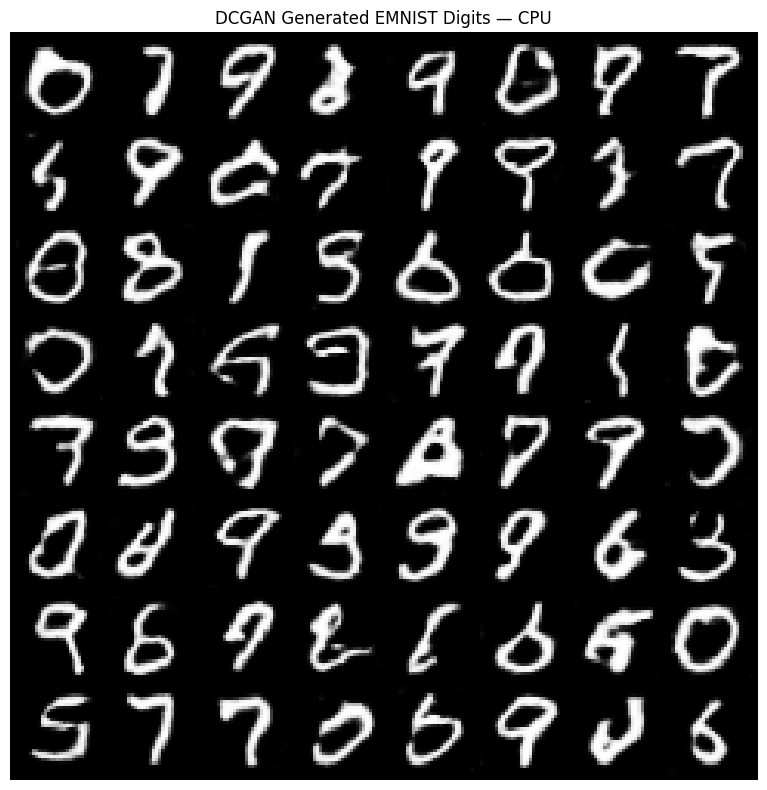

In [12]:
G.eval()

set_seed(SEED)

with torch.no_grad():
    fixed_z = torch.randn(
        DISPLAY_SAMPLES,
        LATENT_DIM,
        device=device,
    )

    samples = G(fixed_z)
    samples = (
        samples.add(1.0)
        .div(2.0)
        .clamp(0.0, 1.0)
        .cpu()
    )

grid = make_grid(
    samples,
    nrow=8,
    padding=2,
)

fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(
    grid.permute(1, 2, 0).squeeze(),
    cmap="gray",
)

ax.axis("off")
ax.set_title(f"DCGAN Generated EMNIST Digits — {DEVICE.upper()}")

fig.tight_layout()
fig.savefig(
    f"dcgan_emnist_{device.type}_samples.png",
    dpi=160,
)

plt.show()


## 13. Final summary and outputs

In [13]:
summary_df = pd.DataFrame([{
    "model": "DCGAN",
    "device": device.type,
    "train_images": len(X_train),
    "test_images": len(X_test),
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "latent_dim": LATENT_DIM,
    "training_time_s": training_time_s,
    "training_throughput_real_images_s": training_throughput,
    "final_discriminator_loss": history_df["d_loss"].iloc[-1],
    "final_generator_loss": history_df["g_loss"].iloc[-1],
    "generation_samples": GENERATION_SAMPLES,
    "generation_time_s": generation_time_s,
    "generation_throughput_images_s": generation_throughput,
    "peak_process_ram_mb": peak_process_ram_mb,
    "peak_gpu_allocated_mb": peak_gpu_allocated_mb,
    "energy_wh_per_1000_images_mean": mean_wh_per_1k,
    "energy_wh_per_1000_images_std": std_wh_per_1k,
    "co2_g_per_1000_images_mean": mean_co2_g_per_1k,
    "co2_g_per_1000_images_std": std_co2_g_per_1k,
    "estimated_full_training_energy_wh": estimated_training_energy_wh,
    "estimated_full_training_co2_g": estimated_training_co2_g,
}])

display(summary_df.round(8))

output_dir = (
    Path("/kaggle/working")
    if Path("/kaggle/working").exists()
    else Path(".")
)

history_df.to_csv(
    output_dir / f"dcgan_emnist_{device.type}_history.csv",
    index=False,
)

energy_df.to_csv(
    output_dir / f"dcgan_emnist_{device.type}_codecarbon.csv",
    index=False,
)

summary_df.to_csv(
    output_dir / f"dcgan_emnist_{device.type}_summary.csv",
    index=False,
)

print("Saved outputs to:", output_dir)


,model,device,train_images,test_images,epochs,batch_size,latent_dim,training_time_s,training_throughput_real_images_s,final_discriminator_loss,...,generation_time_s,generation_throughput_images_s,peak_process_ram_mb,peak_gpu_allocated_mb,energy_wh_per_1000_images_mean,energy_wh_per_1000_images_std,co2_g_per_1000_images_mean,co2_g_per_1000_images_std,estimated_full_training_energy_wh,estimated_full_training_co2_g
0,DCGAN,cpu,240000,40000,5,256,100,2618.710062,458.240879,0.613833,...,2.161377,4626.680329,1826.796875,NaN,0.010654,0.000118,0.002851,0.000032,12.784874,3.421514


Saved outputs to: /kaggle/working


# Reporting rule

Compare only:

\[
\boxed{\text{DCGAN CPU vs DCGAN GPU}}
\]

For the hardware comparison report:

- CPU/GPU training speedup;
- CPU/GPU image-generation speedup;
- energy per 1,000 real training images;
- estimated full-training energy;
- estimated full-training CO₂e;
- peak memory;
- generator/discriminator losses.

Do **not** use raw DCGAN-vs-VAE training times as a direct hardware-efficiency
ranking because VAE and DCGAN perform different training computations.
